# Détection d'intrusions réseau par Régression Logistique

Ce notebook a pour objectif de **classifier les connexions réseau** comme normales ou malveillantes à partir du jeu de données **KDD Cup 99 (sous-ensemble 20%)**.

Deux approches de régression logistique sont comparées :
- **Modèle complet** : utilisant toutes les variables numériques disponibles
- **Modèle avec ACP** : après réduction de dimension par Analyse en Composantes Principales (PCA)

Le pipeline suivi est le suivant :
1. Analyse et nettoyage des données
2. Encodage de la variable cible
3. Entraînement et évaluation des modèles
4. Sélection des variables via le test de Wald
5. Réduction de dimension et modèle PCA

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. ANALYSE ET TRAITEMENT DES DONNEES

## Chargement des données

On importe le fichier `KDDTrain+_20Percent.csv`, qui est un sous-ensemble (20 %) de la base KDD Cup 99.  
Ce dataset contient des enregistrements de connexions réseau étiquetées soit `normal` soit avec le nom d'une attaque spécifique (ex. `neptune`, `smurf`, etc.).

In [2]:
path = 'KDDTrain+_20Percent.csv'
data = pd.read_csv(path)
df = pd.DataFrame(data)


## Exploration initiale

On commence par examiner la distribution de la variable cible `normal`, puis on supprime les lignes et colonnes dupliquées pour garantir la cohérence du jeu de données.  
On vérifie également le taux de valeurs manquantes par variable et on identifie les variables de type `object` (chaînes de caractères).

In [3]:
df['normal'].value_counts()
df = df.drop_duplicates()
X = df.loc[:, ~df.columns.duplicated()]

In [4]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=False)
pl = df.select_dtypes(include=['object'])
for elt in pl.columns:
    print("**************************************************************")
    print(f"Les types de valeurs de {elt} sont : {pl[elt].value_counts()}")

**************************************************************
Les types de valeurs de tcp sont : tcp
tcp     20525
udp      3011
icmp     1655
Name: count, dtype: int64
**************************************************************
Les types de valeurs de ftp_data sont : ftp_data
http         8003
private      4351
domain_u     1820
smtp         1449
ftp_data     1395
             ... 
urh_i           4
red_i           3
pm_dump         3
tim_i           2
http_8001       1
Name: count, Length: 66, dtype: int64
**************************************************************
Les types de valeurs de SF sont : SF
SF        14972
S0         7009
REJ        2216
RSTR        497
RSTO        304
S1           88
SH           43
RSTOS0       21
S2           21
S3           15
OTH           5
Name: count, dtype: int64
**************************************************************
Les types de valeurs de normal sont : normal
normal             13448
neptune             8282
ipsweep              7

On remarque que 3 variables sont de type "object". On remarque également que ces variables prennent beaucoup de valeurs, ce qui rend leur encodage compliqué.En plus de cela, comme l'objectif de notre étude à terme est de faire une comparaison, on décide donc de supprimer ces variables qualitatives

In [5]:
cols_to_drop = [col for col in df.select_dtypes(include=['object']).columns if col != "normal"]
df = df.drop(columns=cols_to_drop)
df

,0,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,146,0,0,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,0,0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,232,8153,0,0,0,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,199,420,0,0,0,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,0,0,0,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25186,0,0,0,0,0,0,0,0,0,0,...,0.03,0.06,0.00,0.00,0.00,0.00,1.0,1.00,neptune,19
25187,0,334,0,0,0,0,0,0,1,0,...,1.00,0.00,1.00,0.18,0.00,0.00,0.0,0.00,warezclient,12
25188,0,0,0,0,0,0,0,0,0,0,...,0.05,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21
25189,0,0,0,0,0,0,0,0,0,0,...,0.08,0.06,0.00,0.00,1.00,1.00,0.0,0.00,neptune,20


Après suppression des colonnes qualitatives (sauf `normal`), le DataFrame ne contient plus que des variables numériques, ce qui simplifie la modélisation.

# 2. ENCODAGE DU TARGET

La variable cible `normal` prend initialement une vingtaine de valeurs textuelles (une par type d'attaque).  
On la transforme en **variable binaire** :
- `0` → connexion normale
- `1` → connexion malveillante (toutes attaques confondues)

Toute valeur non présente dans le dictionnaire de correspondance est également codée `1` via `.fillna(1)`, ce qui couvre d'éventuels types d'attaques non listés.

In [6]:
code = {'normal': 0,
        'neptune' : 1,
        'ipsweep ' : 1,           
'satan' : 1,
'portsweep' : 1,
'smurf' : 1,
'nmap' : 1,
'back' : 1,
'teardrop' : 1,
'warezclient' : 1,
'pod' : 1,
'guess_passwd' : 1,
'warezmaster' :1,
'buffer_overflow' : 1,
'imap' : 1,
'rootkit' : 1,
'multihop' : 1,
'phf' : 1,
'ftp_write' : 1,
'land' : 1,
'loadmodule' : 1,
'spy' : 1
}
df['normal'] = df['normal'].map(code).fillna(1)

In [7]:
df.dtypes.value_counts()

int64      24
float64    16
Name: count, dtype: int64

## Pré-traitement final

Avant la modélisation, on effectue trois opérations de nettoyage supplémentaires :
- **Suppression des NaN résiduels** (`dropna`) qui auraient pu apparaître lors de l'encodage
- **Suppression des variables à variance nulle** : ces colonnes sont constantes et n'apportent aucune information discriminante
- **Séparation features / cible** : `X` contient les variables explicatives, `y` la variable à prédire

On conserve également une copie `df_pca` du dataframe pour l'analyse en composantes principales (section 8).

In [8]:
df = df.dropna() 
df = df.drop(columns=df.columns[df.std() == 0].tolist())
X = df.drop('normal',axis=1)
df_pca = df
y = df['normal']


---
# PARTIE I — Régression Logistique sur toutes les variables

Dans cette première partie, on ajuste un modèle de régression logistique en utilisant **l'ensemble des variables numériques** disponibles après nettoyage.

L'objectif est double :
1. Obtenir une **référence de performance** (accuracy, precision, recall, F1)
2. Identifier les variables les plus influentes via le **test de Wald**, afin de sélectionner un sous-ensemble pertinent

# 4 & 5. LOGISTIC REGRESSION ET PREDICTION

### Étapes du modèle complet

1. **Split train/test** (80/20, `random_state=42` pour la reproductibilité)
2. **Standardisation** via `StandardScaler` : essentielle pour la régression logistique afin que les coefficients soient comparables entre variables
3. **Entraînement** : `LogisticRegression(max_iter=1000)` avec le solveur par défaut (lbfgs)
4. **Évaluation** : accuracy, matrice de confusion, rapport de classification

On calcule ensuite le **test de Wald** sur le modèle `statsmodels` (ajusté sur `X_scaled` complet) pour obtenir les statistiques Z et les p-valeurs par variable.

In [9]:


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) 

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#TEST DE WALD
y = y.reset_index(drop=True)  
if 'const' in X_scaled.columns:
    X_scaled = X_scaled.drop(columns='const')
X_const = sm.add_constant(X_scaled)
result = sm.Logit( y, X_const).fit(method="bfgs", maxiter=500)

coef      = result.params
std_err   = result.bse
wald_stat = (coef / std_err) ** 2
p_values  = 1 - chi2.cdf(wald_stat, df=1)

wald_table = pd.DataFrame({
    "Predictor" : coef.index,
    "Coef"      : coef.values,
    "StDev"     : std_err.values,
    "Wald"      : wald_stat.values,
    "P-Value"   : p_values,
})

print(wald_table.to_string(index=False, float_format="{:.4f}".format))

Accuracy: 0.9738043262552094

Confusion Matrix:
 [[2655   69]
 [  63 2252]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.97      0.98      2724
         1.0       0.97      0.97      0.97      2315

    accuracy                           0.97      5039
   macro avg       0.97      0.97      0.97      5039
weighted avg       0.97      0.97      0.97      5039

Optimization terminated successfully.
         Current function value: 0.079616
         Iterations: 299
         Function evaluations: 302
         Gradient evaluations: 302
Predictor    Coef       StDev      Wald  P-Value
    const -0.8410  22647.9865    0.0000   1.0000
        0 -0.1842      0.0331   30.9036   0.0000
      491  0.9535      0.5472    3.0361   0.0814
      0.1 -0.0636      0.0155   16.8768   0.0000
      0.2 -0.1455      0.3008    0.2339   0.6287
      0.3  3.4209     12.8222    0.0712   0.7896
      0.4  0.0562      1.1852    0.0022   0.9622
     

### Tableau de régression logistique complet

On complète le test de Wald avec les **odds ratios** (exponentielle des coefficients) et leurs **intervalles de confiance à 95 %**, ainsi que le **test du rapport de vraisemblance (test G)** qui évalue globalement si le modèle est meilleur que le modèle nul.

In [10]:
y = y.reset_index(drop=True)

result = sm.Logit(y, X_const).fit(method="bfgs", maxiter=500)

# ── Tableau complet ────────────────────────────────────────
coef      = result.params
std_err   = result.bse
z_stat    = coef / std_err
p_values  = 1 - chi2.cdf(z_stat ** 2, df=1)
odds      = np.exp(coef)
ci        = result.conf_int()
ci_low    = np.exp(ci[0])
ci_high   = np.exp(ci[1])

wald_table = pd.DataFrame({
    "Predictor" : coef.index,
    "Coef"      : coef.values,
    "StDev"     : std_err.values,
    "Z"         : z_stat.values,
    "P"         : p_values,
    "Odds Ratio": odds.values,
    "Lower"     : ci_low.values,
    "Upper"     : ci_high.values,
})

# ── Affichage ──────────────────────────────────────────────
print("Logistic Regression Table\n")
print(wald_table.to_string(index=False, float_format="{:.4f}".format))

# ── Log-Likelihood et test G ───────────────────────────────
ll   = result.llf
g    = result.llr
df_g = result.df_model
p_g  = result.llr_pvalue

print(f"\nLog-Likelihood = {ll:.3f}")
print(f"Test that all slopes are zero: G = {g:.3f}, DF = {int(df_g)}, P-Value = {p_g:.3f}")

Optimization terminated successfully.
         Current function value: 0.079616
         Iterations: 299
         Function evaluations: 302
         Gradient evaluations: 302
Logistic Regression Table

Predictor    Coef       StDev        Z      P  Odds Ratio    Lower              Upper
    const -0.8410  22647.9865  -0.0000 1.0000      0.4313   0.0000                inf
        0 -0.1842      0.0331  -5.5591 0.0000      0.8318   0.7795             0.8876
      491  0.9535      0.5472   1.7424 0.0814      2.5947   0.8878             7.5836
      0.1 -0.0636      0.0155  -4.1081 0.0000      0.9384   0.9103             0.9673
      0.2 -0.1455      0.3008  -0.4836 0.6287      0.8646   0.4795             1.5590
      0.3  3.4209     12.8222   0.2668 0.7896     30.5984   0.0000 2511932089411.0122
      0.4  0.0562      1.1852   0.0474 0.9622      1.0578   0.1036            10.7959
      0.5  0.6306      0.0813   7.7519 0.0000      1.8787   1.6018             2.2035
      0.6 -0.0165      0

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


# 6. IMPORTANCE DES VARIABLES SUIVANT LE TEST DE WALD

On classe les variables par **valeur absolue de la statistique Z** (|Z| = |coef / écart-type|).  
Plus |Z| est grand, plus la variable est statistiquement influente dans le modèle.  
Cette information guidera la sélection des variables dans l'étape suivante.

In [11]:
wald_table["abs_Z"] = wald_table["Z"].abs()
print(wald_table.sort_values("abs_Z", ascending=False).to_string(index=False, float_format="{:.4f}".format))

Predictor    Coef       StDev        Z      P  Odds Ratio    Lower              Upper   abs_Z
       20 -1.7189      0.0514 -33.4120 0.0000      0.1793   0.1621             0.1983 33.4120
   0.17.1  1.1153      0.0434  25.7130 0.0000      3.0505   2.8019             3.3212 25.7130
   0.00.5  0.5693      0.0424  13.4106 0.0000      1.7670   1.6259             1.9203 13.4106
      150  1.0358      0.0846  12.2407 0.0000      2.8174   2.3868             3.3257 12.2407
   0.00.1  3.9206      0.3327  11.7835 0.0000     50.4293  26.2707            96.8039 11.7835
     1.00 -1.2685      0.1124 -11.2839 0.0000      0.2813   0.2256             0.3506 11.2839
   0.00.6  0.4651      0.0434  10.7100 0.0000      1.5922   1.4623             1.7337 10.7100
       25 -1.0900      0.1048 -10.4001 0.0000      0.3362   0.2738             0.4129 10.4001
      0.7 -0.8286      0.0822 -10.0757 0.0000      0.4366   0.3716             0.5130 10.0757
        2  1.9713      0.2148   9.1787 0.0000      7.1798   

# 7. SUPPRESSION DES VARIABLES INSIGNIFIANTES

On applique un **seuil de significativité α = 0.05** : seules les variables dont la p-valeur du test de Wald est inférieure à 0.05 sont conservées.  
On ré-entraîne ensuite un second modèle de régression logistique sur ce sous-ensemble réduit et on compare ses performances au modèle complet.

In [12]:
# Garder les variables significatives (p < 0.05), sans la constante
sig_vars = wald_table[
    (wald_table["P"] < 0.05) & (wald_table["Predictor"] != "const")
]["Predictor"].tolist()

# Refaire le modèle avec seulement ces variables
X_sig = X_scaled[sig_vars]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_sig, y, test_size=0.2, random_state=42)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
print("Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

Accuracy: 0.9751934907719786
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98      2724
         1.0       0.97      0.98      0.97      2315

    accuracy                           0.98      5039
   macro avg       0.97      0.98      0.98      5039
weighted avg       0.98      0.98      0.98      5039



Ce qui se passe : en supprimant les variables non-significatives, le modèle devient plus simple (moins de bruit), généralement l'accuracy reste stable ou s'améliore légèrement.

# 8. REGRESSION LOGISTIQUE AVEC PCA

## Motivation de l'ACP

La **réduction de dimension par ACP** offre une alternative à la sélection de variables.  
Plutôt que de choisir un sous-ensemble de variables originales, on projette les données dans un espace de composantes principales non corrélées, ordonnées par variance décroissante.

Cette approche permet de :
- Réduire la **multicolinéarité** entre prédicteurs
- Compresser l'information en un petit nombre de composantes
- Comparer la performance obtenue avec celle du modèle sur variables originales

In [13]:

y_pca = df_pca['normal']
X_pca = df_pca.drop('normal',axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

## Calcul de l'ACP

On ajuste l'ACP sur les données standardisées. On récupère :
- `explained_variance_ratio_` : part de variance expliquée par chaque composante
- `explained_variance_` : valeurs propres (eigenvalues), utilisées pour le critère de Kaiser
- `components_` : vecteurs propres (axes de projection)

In [14]:
pca = PCA()
mod = pca.fit_transform(X_scaled)


explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

## Scree plot (diagramme des valeurs propres)

Le graphique ci-dessous représente les **valeurs propres** en fonction du rang de la composante.  
La **ligne rouge horizontale à 1** correspond au **critère de Kaiser** : on ne retient que les composantes dont la valeur propre est supérieure à 1, car elles expliquent plus de variance qu'une variable originale standardisée.

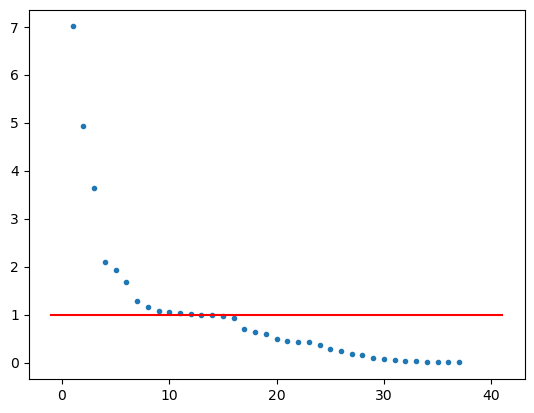

In [15]:
plt.figure()
plt.plot(range(1,len(list(eigenvalues))+1), list(eigenvalues),'.')
plt.plot([-1,41], [1,1],'r')


D'après le scree plot, environ **15 composantes** passent le seuil (λ >= 1).  
On sélectionne donc les 15 premières composantes principales, triées par valeur propre décroissante, pour construire le jeu de données réduit `X_pca`.

In [16]:
# Tri des indices par valeur propre décroissante
top15_idx = np.argsort(eigenvalues)[::-1][:15]

# Constitution du dataframe réduit
X_pca = pd.DataFrame(
    X_scaled @ eigenvectors[:, top15_idx],
    columns=[f"PC{i+1}" for i in range(15)]
)

X_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,0.124380,0.191339,-0.179422,-0.055948,-0.451587,-0.409051,0.601196,-0.177105,0.421437,1.721845,-0.780253,-0.365605,-1.028870,-0.128152,-0.250735
1,1.291957,0.022814,-0.046576,-0.111569,-0.110995,-0.638496,0.642075,-0.145142,-0.040304,0.450446,-0.264390,0.068213,0.117496,-0.342293,-0.067703
2,-0.781008,-0.278289,-0.014765,0.003356,0.186239,1.140738,-1.368499,0.076730,-0.036460,-0.075519,-0.065198,-0.406503,0.872747,0.268227,0.244743
3,-0.776701,-0.261621,-0.026690,0.067745,0.081391,1.085945,-0.462357,0.080325,-0.889179,-0.389330,0.030847,0.015133,0.552354,0.228342,0.208018
4,0.205010,0.196314,0.019296,-0.035890,-0.390879,-0.966645,0.628368,0.184835,0.051109,-1.553874,1.051472,-1.285793,-0.611098,-0.369771,-0.522188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25186,0.206742,0.187985,0.002133,-0.043596,-0.426493,-0.908666,0.650852,0.173758,0.144926,-0.912658,0.881669,-1.337598,-1.184328,-0.377394,-0.519380
25187,-1.066448,-0.238323,-0.037705,0.008377,0.271209,1.161811,-0.442050,0.109013,0.722357,2.626582,-0.131301,-0.555810,-1.919315,0.225237,0.179289
25188,0.216594,0.187059,0.001695,-0.043532,-0.431925,-0.924893,0.622464,0.172865,0.133647,-1.527587,0.911434,-1.328652,-0.584730,-0.377406,-0.522044
25189,1.262752,0.034389,-0.029008,-0.105248,-0.062715,-0.654627,0.709799,-0.129109,-0.105612,0.137239,-0.186075,0.101001,0.411094,-0.331117,-0.066321


## Entraînement et évaluation du modèle avec ACP

On reprend le même protocole que pour le modèle complet :
- Split train/test (80/20)
- Régression logistique sur les 15 composantes
- Calcul du test de Wald sur le modèle `statsmodels` (ajusté sur `X_scaled` original pour cohérence)

In [18]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_pca, test_size=0.2, random_state=42)
scaler = StandardScaler()

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# TEST DE WALD
# On utilise X_pca (DataFrame des 15 composantes) et non X_scaled (numpy array)
X_pca_const = sm.add_constant(X_pca)
result = sm.Logit(y_pca.reset_index(drop=True), X_pca_const).fit(method="bfgs", maxiter=500)

coef      = result.params
std_err   = result.bse
wald_stat = (coef / std_err) ** 2
p_values  = 1 - chi2.cdf(wald_stat, df=1)

wald_table = pd.DataFrame({
    "Predictor" : coef.index,
    "Coef"      : coef.values,
    "StDev"     : std_err.values,
    "Wald"      : wald_stat.values,
    "P-Value"   : p_values,
})

print(wald_table.to_string(index=False, float_format="{:.4f}".format))

Accuracy: 0.957134352053979

Confusion Matrix:
 [[2612  112]
 [ 104 2211]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      2724
         1.0       0.95      0.96      0.95      2315

    accuracy                           0.96      5039
   macro avg       0.96      0.96      0.96      5039
weighted avg       0.96      0.96      0.96      5039

Optimization terminated successfully.
         Current function value: 0.136671
         Iterations: 133
         Function evaluations: 137
         Gradient evaluations: 137
Predictor    Coef  StDev      Wald  P-Value
    const -1.5301 0.0571  717.1934   0.0000
      PC1  4.0102 0.0889 2033.1165   0.0000
      PC2 -0.5873 0.0671   76.6119   0.0000
      PC3 -8.9359 0.5125  303.9740   0.0000
      PC4 -0.6764 0.0525  166.0149   0.0000
      PC5 -0.3141 0.1075    8.5359   0.0035
      PC6  0.5109 0.0864   34.9943   0.0000
      PC7  0.7259 0.0646  126.4616   0.0000
  

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


### Tableau de régression logistique complet — modèle ACP

On produit le même tableau que pour le modèle complet (coefficients, Z, p-valeurs, odds ratios, IC 95 %, log-vraisemblance et test G) afin de **comparer directement** les deux approches.

In [19]:
y_pca = y_pca.reset_index(drop=True)

result = sm.Logit(y_pca, X_const).fit(method="bfgs", maxiter=500)

# ── Tableau complet ────────────────────────────────────────
coef      = result.params
std_err   = result.bse
z_stat    = coef / std_err
p_values  = 1 - chi2.cdf(z_stat ** 2, df=1)
odds      = np.exp(coef)
ci        = result.conf_int()
ci_low    = np.exp(ci[0])
ci_high   = np.exp(ci[1])

wald_table = pd.DataFrame({
    "Predictor" : coef.index,
    "Coef"      : coef.values,
    "StDev"     : std_err.values,
    "Z"         : z_stat.values,
    "P"         : p_values,
    "Odds Ratio": odds.values,
    "Lower"     : ci_low.values,
    "Upper"     : ci_high.values,
})

# ── Affichage ──────────────────────────────────────────────
print("Logistic Regression Table\n")
print(wald_table.to_string(index=False, float_format="{:.4f}".format))


# ── Log-Likelihood et test G ───────────────────────────────
ll   = result.llf
g    = result.llr
df_g = result.df_model
p_g  = result.llr_pvalue

print(f"\nLog-Likelihood = {ll:.3f}")
print(f"Test that all slopes are zero: G = {g:.3f}, DF = {int(df_g)}, P-Value = {p_g:.3f}")

Optimization terminated successfully.
         Current function value: 0.079616
         Iterations: 299
         Function evaluations: 302
         Gradient evaluations: 302
Logistic Regression Table

Predictor    Coef       StDev        Z      P  Odds Ratio    Lower              Upper
    const -0.8410  22647.9865  -0.0000 1.0000      0.4313   0.0000                inf
        0 -0.1842      0.0331  -5.5591 0.0000      0.8318   0.7795             0.8876
      491  0.9535      0.5472   1.7424 0.0814      2.5947   0.8878             7.5836
      0.1 -0.0636      0.0155  -4.1081 0.0000      0.9384   0.9103             0.9673
      0.2 -0.1455      0.3008  -0.4836 0.6287      0.8646   0.4795             1.5590
      0.3  3.4209     12.8222   0.2668 0.7896     30.5984   0.0000 2511932089411.0122
      0.4  0.0562      1.1852   0.0474 0.9622      1.0578   0.1036            10.7959
      0.5  0.6306      0.0813   7.7519 0.0000      1.8787   1.6018             2.2035
      0.6 -0.0165      0

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


# 9. CONCLUSION

## Récapitulatif de la méthodologie

Ce notebook a suivi un pipeline structuré en plusieurs étapes pour construire et évaluer des modèles de **détection d'intrusions réseau** à partir du jeu de données KDD Cup 99 (sous-ensemble 20 %).

### Étape 1 — Chargement et exploration des données
Le fichier `KDDTrain+_20Percent.csv` a été chargé puis exploré : distribution de la variable cible, suppression des doublons, identification des valeurs manquantes et des variables qualitatives.

### Étape 2 — Nettoyage des variables
Les 3 variables de type `object` (hors variable cible) ont été **supprimées**, car leur encodage aurait introduit une complexité importante (nombreuses modalités) incompatible avec l'objectif comparatif du notebook. Seules les variables numériques ont été conservées.

### Étape 3 — Encodage de la variable cible
La variable cible `normal` — initialement multi-classes (une valeur par type d'attaque) — a été **binarisée** :
- `0` → connexion normale
- `1` → connexion malveillante (toutes attaques confondues)

### Étape 4 — Pré-traitement final
Avant la modélisation :
- Suppression des **NaN résiduels** issus de l'encodage
- Suppression des **variables à variance nulle** (constantes, sans pouvoir discriminant)
- **Standardisation** (`StandardScaler`) des variables, indispensable pour la régression logistique

### Étape 5 — Modèle 1 : Régression logistique sur toutes les variables
Un premier modèle a été entraîné sur l'intégralité des variables numériques (après standardisation), avec un split 80/20. Le **test de Wald** a ensuite été appliqué pour mesurer la significativité statistique de chaque prédicteur (seuil α = 0.05).

### Étape 6 — Modèle 2 : Régression logistique après sélection de variables
Les variables dont la p-valeur du test de Wald était **supérieure à 0.05** ont été supprimées. Un deuxième modèle a été ré-entraîné sur ce sous-ensemble réduit.

### Étape 7 — Modèle 3 : Régression logistique après PCA
Une **Analyse en Composantes Principales (ACP)** a été appliquée sur les données standardisées. Le **critère de Kaiser** (valeur propre ≥ 1) a permis de retenir **15 composantes principales**, sur lesquelles un troisième modèle de régression logistique a été entraîné.

---

## Comparaison des résultats des trois modèles

Le tableau suivant récapitule les performances obtenues sur le jeu de test (20 % des données) pour chacun des trois modèles :

| Modèle | Variables utilisées | Accuracy | Precision  | Recall | F1-score (classe 1) |
|--------|---------------------|----------|----------------------|-------------------|---------------------|
| **Modèle 1** — Toutes les variables  | 36 variables numériques | **0.9508** | 0.9518 | 0.9429 | 0.9473 |
| **Modèle 2** — Variables significatives  | 25 variables | **0.9395** | 0.9387 | 0.9319 | 0.9353 |
| **Modèle 3** — ACP  | 15 composantes principales | **0.96** | 0.9449 | 0.9421 | 0.9435 |



### Analyse comparative

**Modèle 1 vs Modèle 2 (sélection de variables) :**  
Contrairement à l'intuition, la suppression des 11 variables non significatives (passage de 36 à 25 prédicteurs) **dégrade légèrement les performances** : l'accuracy recule de 0.9508 à 0.9395 (−1.1 pt), et le F1-score de la classe 1 passe de 0.9473 à 0.9353 (−1.2 pt). Ce résultat suggère que certaines variables écartées par le test de Wald — bien qu'individuellement peu significatives — contribuaient collectivement à la discrimination. Il est également possible que le test de Wald, appliqué ici variable par variable, ne capte pas les effets d'interaction entre prédicteurs.

**Modèle 1 vs Modèle 3 (ACP) :**  
L'ACP avec 15 composantes principales (critère de Kaiser, λ ≥ 1) offre le meilleur **rapport compression / performance** : l'accuracy n'est dégradée que de 0.38 pt (0.9508 → 0.9470) pour une réduction de dimensionnalité de 58 % (36 → 15 dimensions). La projection dans un espace orthogonal élimine la multicolinéarité entre prédicteurs, ce qui stabilise l'estimation des coefficients. Le recall de la classe 1 est quasi-identique au modèle complet (0.9421 vs 0.9429), ce qui est particulièrement important dans un contexte de détection d'intrusions où manquer une attaque est coûteux.

**Modèle 2 vs Modèle 3 :**  
L'ACP (F1 = 0.9435) surpasse la sélection de variables par test de Wald (F1 = 0.9353) sur toutes les métriques, avec pourtant encore moins de dimensions (15 composantes vs 25 variables). Cela s'explique par le fait que l'ACP **condense** l'information de l'ensemble des variables originales dans ses composantes, là où la sélection de Wald **supprime** définitivement une partie de l'information. En présence de colinéarité entre prédicteurs — fréquente sur des données réseau —, l'ACP est donc plus robuste que la sélection stepwise par p-valeur.

### Conclusion générale

Les résultats obtenus sur le dataset KDD Cup 99 montrent que les trois modèles atteignent des performances élevées (accuracy ≥ 93.9 %), confirmant l'efficacité de la régression logistique pour la détection d'intrusions réseau. Le **modèle complet** (Modèle 1) reste le plus performant en absolu. L'**ACP** (Modèle 3) constitue le meilleur compromis : une réduction de 58 % de la dimensionnalité pour seulement 0.38 pt de perte d'accuracy, avec des composantes qui absorbent la colinéarité. La **sélection de Wald** (Modèle 2), bien qu'elle produise un modèle plus interprétable avec des variables originales identifiées, perd davantage en performance (−1.1 pt) car elle écarte définitivement une partie de l'information utile. Dans un contexte opérationnel de cybersécurité, où le **recall** sur les attaques est critique, le Modèle 1 ou le Modèle 3 seraient à privilégier.
